# ***Hyperparameter Optimization for Titanic Survival Prediction***

## Import librares


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## load dataset


In [2]:
titanic=sns.load_dataset("titanic")
titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
# convert male column string to float

titanic = pd.get_dummies(titanic, drop_first=True)

## prepared data

In [5]:
x=titanic.drop("survived",axis=1)
y=titanic['survived']

## Split data

In [6]:
X_train,X_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)


(712, 23)
(712,)
(179, 23)
(179,)


## Train model using tree

In [8]:
model= DecisionTreeClassifier()

model.fit(X_train,y_train)

y_predict=model.predict(X_test)

## model evaluation

In [9]:
print("accuracy_score:", accuracy_score(y_test,y_predict))
print("precision_score:",precision_score(y_test,y_predict))
print("f1_score:",f1_score(y_test,y_predict))
print("recall_score:",recall_score(y_test,y_predict))

accuracy_score: 1.0
precision_score: 1.0
f1_score: 1.0
recall_score: 1.0


## Display Confusion matrix

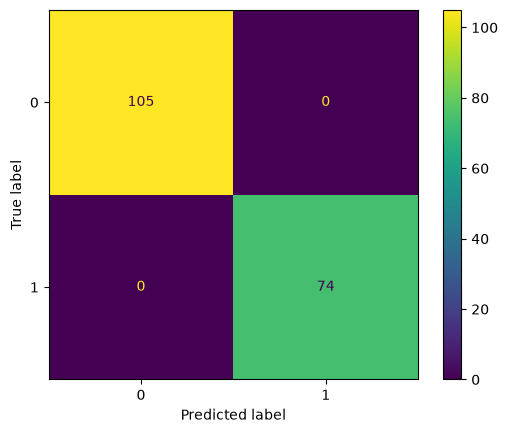

In [10]:
cm=(y_test,y_predict)

ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)

plt.savefig("sonfusion.png")

## Grid Search (GridSearchcv)

- when we don't know which one is best setting so we tell the computer they create diffrent combination and compare them and find high accuracy setting and used thoe setting

In [11]:
param_grid={
    'max_depth':[3,5,7,9],
    'criterion':['gini','entropy'],
    'min_samples_split':[2,5,10]
}

how much combination they would try so:  
max_depth=4  
criterion=2  
min_samples_split=3  
So:  
total_combination = 4 * 2 * 3=24  

In [12]:
grid=GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5,  #Cross Validation.
    scoring='accuracy'
)

In [13]:
# tarin model
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Co

In [14]:
# git best setting which one they are select

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


### Best score

In [15]:
print(grid.best_score_)

1.0


### Best model

In [16]:
print(grid.best_estimator_)

DecisionTreeClassifier(max_depth=3)


## Evalution of the grid search

In [17]:
y_pred_grid = grid.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_grid))
print("Precision:", precision_score(y_test, y_pred_grid))
print("Recall   :", recall_score(y_test, y_pred_grid))
print("F1 Score :", f1_score(y_test, y_pred_grid))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## Randomized Search

In [18]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import RandomizedSearchCV

# choose search space

param_dictionary={
    'max_depth':[2,3,4,5,6,7,8,9,10],
    'criterion':['gini','entropy'],
    'min_samples_split':[2,4,6,8,10]
}


In [19]:
# Run random search

random_search=RandomizedSearchCV(
    estimator=DecisionTreeClassifier(),
    param_distributions=param_dictionary,
    n_iter=10,
    cv=5,
    random_state=42
)

In [20]:
# Train model

random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_split': [2, 4, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes `

In [21]:
# best parameter

print(random_search.best_params_)

{'min_samples_split': 2, 'max_depth': 10, 'criterion': 'gini'}


In [22]:
# best model
y_pred_random=random_search.predict(X_test)
y_pred_random


array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1])

## Accuracy Score

In [23]:
accuracy_score(y_test,y_pred_random)

1.0

## Print Best Hyperparameters

In [24]:
print("Grid Search best parameter:",grid.best_params_)
print("Random Search best parameter:",random_search.best_params_)


Grid Search best parameter: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Random Search best parameter: {'min_samples_split': 2, 'max_depth': 10, 'criterion': 'gini'}


## compare both method

In [25]:
print("Grid Search Best Accuracy :", grid.best_score_)
print("Random Search Best Accuracy :", random_search.best_score_)

print("\nGrid Search Best Parameters:")
print(grid.best_params_)

print("\nRandom Search Best Parameters:")
print(random_search.best_params_)

Grid Search Best Accuracy : 1.0
Random Search Best Accuracy : 1.0

Grid Search Best Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

Random Search Best Parameters:
{'min_samples_split': 2, 'max_depth': 10, 'criterion': 'gini'}


# Bar chart

In [26]:
accuracy_default = accuracy_score(y_test, y_predict)

accuracy_grid = accuracy_score(y_test, y_pred_grid)

accuracy_random = accuracy_score(y_test, y_pred_random)

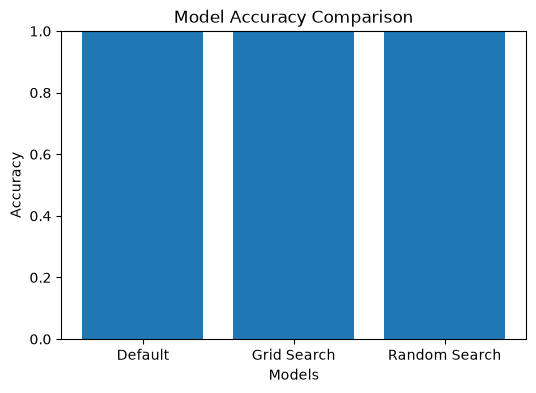

In [27]:

models = ['Default', 'Grid Search', 'Random Search']
accuracies = [accuracy_default, accuracy_grid, accuracy_random]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0, 1)   # Accuracy ranges from 0 to 1

plt.savefig("final bar chart.png")


In [28]:
import joblib

# Save default Decision Tree
joblib.dump(
    model,
    "titanic_logistic.pkl"
)

# Save best GridSearch model
joblib.dump(
    grid.best_estimator_,
    "titanic_grid.pkl"
)

# Save best RandomizedSearch model
joblib.dump(
    random_search.best_estimator_,
    "titanic_random.pkl"
)

print("All Titanic Decision Tree models saved successfully!")

All Titanic Decision Tree models saved successfully!
